[Kaggle airline dataset](https://www.kaggle.com/datasets/rohitgrewal/airlines-flights-data)

In [1]:
%pip install seaborn numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Data/airlines_flights_data.csv', index_col='index')
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
index,,,,,,,,,,,
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


### Data exploration and analysis

In [4]:
print('Data size:', df.size)
print('Data shape:', df.shape)

Data size: 3301683
Data shape: (300153, 11)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 27.5+ MB


In [6]:
df['airline'].unique()

array(['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo',
       'Air_India'], dtype=object)

In [7]:
df.head(10)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
index,,,,,,,,,,,
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
5,Vistara,UK-945,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1,5955
6,Vistara,UK-927,Delhi,Morning,zero,Morning,Mumbai,Economy,2.08,1,6060
7,Vistara,UK-951,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.17,1,6060
8,GO_FIRST,G8-334,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.17,1,5954


In [8]:
df.describe().round(2)

,duration,days_left,price
count,300153.00,300153.00,300153.00
mean,12.22,26.00,20889.66
std,7.19,13.56,22697.77
min,0.83,1.00,1105.00
25%,6.83,15.00,4783.00
50%,11.25,26.00,7425.00
75%,16.17,38.00,42521.00
max,49.83,49.00,123071.00


No null values in dataset. Hence dataset is clean

In [9]:
df.isnull().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [10]:
# days left tells time from the booking date till trip date
df['days_left'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])

In [11]:
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
index,,,,,,,,,,,
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [12]:
# which airine has most flight frequency in data

frq_arl = df.groupby(['airline'])['flight'].count().reset_index()
frq_arl.columns = ['airline', 'flight_count']
frq_arl

,airline,flight_count
0,AirAsia,16098
1,Air_India,80892
2,GO_FIRST,23173
3,Indigo,43120
4,SpiceJet,9011
5,Vistara,127859


### Which Airlines has highest no of flights

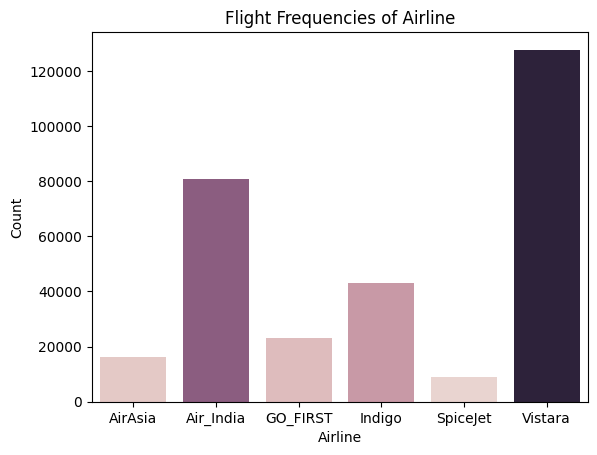

In [13]:
plt.figure()
sns.barplot(data=frq_arl,x='airline', y='flight_count', hue='flight_count', legend=False)
plt.title('Flight Frequencies of Airline')
plt.xlabel('Airline')
plt.ylabel('Count')
plt.show()

Top 3 flights are Air India, Vistara and Indigo

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 27.5+ MB


### Which Airline prefer what time slot for arrival and departure
For simplicity displaying only plot of top 3 airline

In [15]:

ar_flt = df.groupby(['airline'])['arrival_time'].value_counts().reset_index()
ar_flt = ar_flt[ar_flt['airline'].isin(['Air_India', 'Vistara', 'Indigo'])]
ar_flt

,airline,arrival_time,count
6,Air_India,Night,24552
7,Air_India,Morning,20521
8,Air_India,Evening,18748
9,Air_India,Afternoon,11576
10,Air_India,Early_Morning,3405
11,Air_India,Late_Night,2090
18,Indigo,Night,12701
19,Indigo,Evening,11591
20,Indigo,Afternoon,7367
21,Indigo,Morning,5469


In [16]:
airIndia = ar_flt[ar_flt['airline'] == 'Air_India']
Vistara = ar_flt[ar_flt['airline'] == 'Vistara']
Indigo = ar_flt[ar_flt['airline'] == 'Indigo']


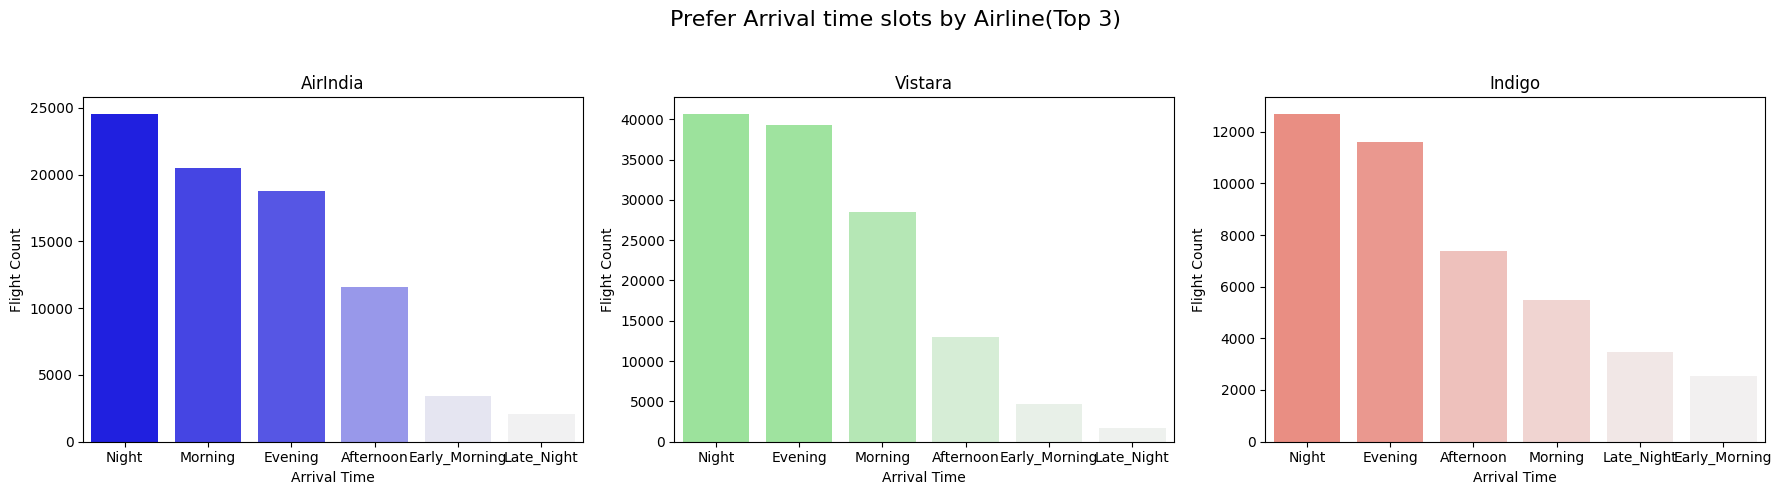

In [17]:
plt.figure(figsize=(18, 5))
plt.suptitle('Prefer Arrival time slots by Airline(Top 3)', fontsize=16)

plt.subplot(1, 3, 1)
sns.barplot(data=airIndia, x='arrival_time', y='count', palette='light:blue', hue='count', legend=False)
plt.title('AirIndia')
plt.xlabel('Arrival Time')
plt.ylabel('Flight Count')


plt.subplot(1, 3, 2)
sns.barplot(data=Vistara, x='arrival_time', y='count',  palette='light:lightgreen', hue='count', legend=False)
plt.title('Vistara')
plt.xlabel('Arrival Time')
plt.ylabel('Flight Count')



plt.subplot(1, 3, 3)
sns.barplot(data=Indigo, x='arrival_time', y='count', palette='light:salmon' ,hue='count', legend=False)
plt.title('Indigo')
plt.xlabel('Arrival Time')
plt.ylabel('Flight Count')

plt.grid(False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

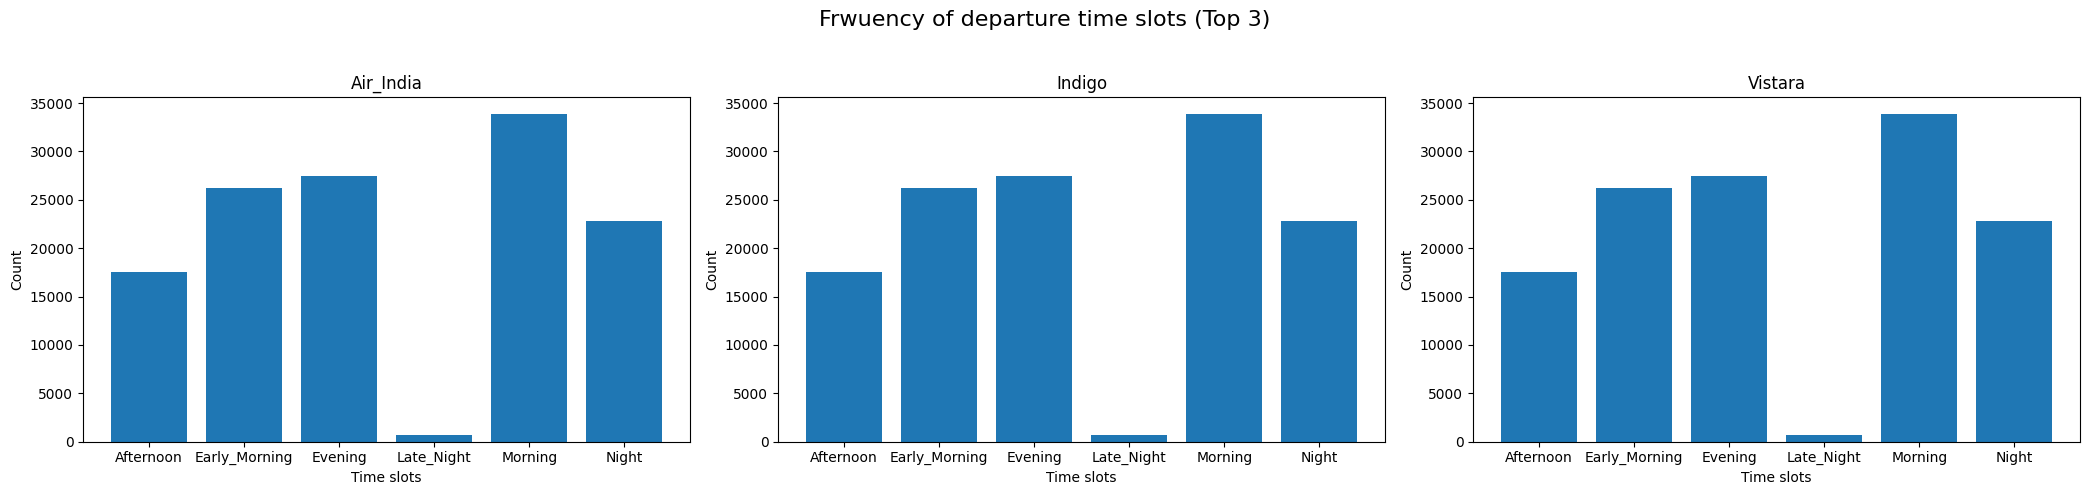

In [18]:
# for arrival

depatre_slots = df.groupby(['airline', 'departure_time']).size().reset_index(name='Count')
# print(depatre_slots)
depatre_slots = depatre_slots[depatre_slots['airline'].isin(['Air_India', 'Vistara', 'Indigo'])]
airlines = depatre_slots['airline'].unique()
# print(airlines)
col = 3
row = 1

fig, axes = plt.subplots(row, col, figsize=(7*col, 5 * row))
fig.suptitle('Frwuency of departure time slots (Top 3)', fontsize=16)
axes = axes.flatten()

for i, airline in enumerate(airlines):
    sb = depatre_slots[depatre_slots['airline'] == airline]
    ax = axes[i]
    ax.bar(depatre_slots['departure_time'], depatre_slots['Count'])
    ax.set_title(airline)
    ax.set_xlabel('Time slots')
    ax.set_ylabel('Count')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [19]:
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
index,,,,,,,,,,,
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


### Class distribution by airlines

In [20]:
cls_compr = df.groupby(['airline', 'class']).size().reset_index(name='count')
cls_compr

,airline,class,count
0,AirAsia,Economy,16098
1,Air_India,Business,32898
2,Air_India,Economy,47994
3,GO_FIRST,Economy,23173
4,Indigo,Economy,43120
5,SpiceJet,Economy,9011
6,Vistara,Business,60589
7,Vistara,Economy,67270


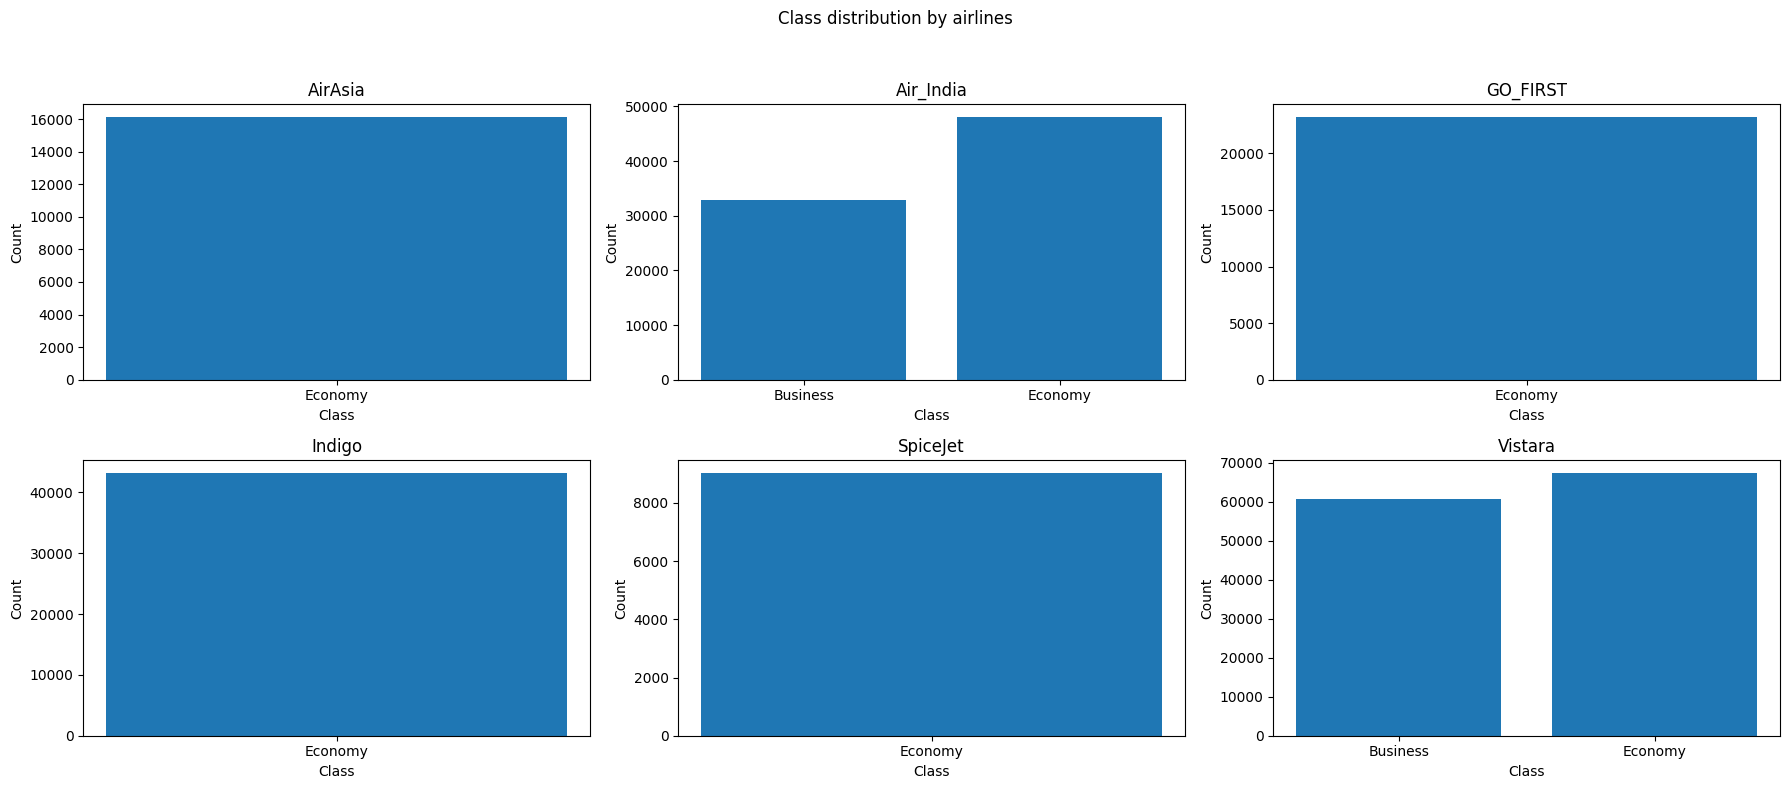

In [21]:
import math

airlines = cls_compr['airline'].unique()
n = len(airlines)

#set the col and row
col = 3
row = math.ceil(n/col)

# figsize = (width, col)
fig, axes = plt.subplots(row, col, figsize=(6 * col, 4 * row))
fig.suptitle('Class distribution by airlines')
# flatten axes array for easy indexing
axes = axes.flatten()

for i, airline in enumerate(airlines):
    subset = cls_compr[cls_compr['airline'] == airline]

    ax = axes[i]
    ax.bar(subset['class'], subset['count'])
    ax.set_title(airline)
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')

# hide any remaining blank axes/subplots if remained
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# adds padding around subplots
# rect = [l, b, r, t]
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Does price varies with airlines

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 27.5+ MB


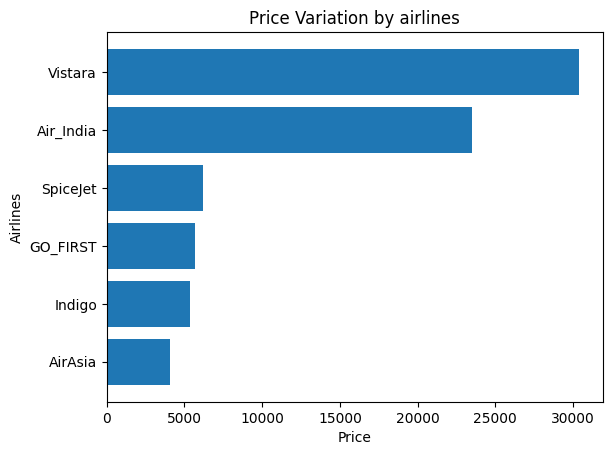

In [23]:
air_price = df.groupby(['airline'])['price'].mean().reset_index().sort_values('price')


plt.barh(air_price['airline'], air_price['price'])
plt.title('Price Variation by airlines')
plt.xlabel('Price')
plt.ylabel('Airlines')
plt.grid(False)
plt.show()

# the bar graph visualize the most expensive airline 

How the price changes with change in Source and Destination?

In [34]:
src_prc = df.groupby(['source_city'])['price'].mean().reset_index().round(2).sort_values('price', ascending=False)
dest_prc = df.groupby(['destination_city'])['price'].mean().reset_index().round(2).sort_values('price', ascending=False)

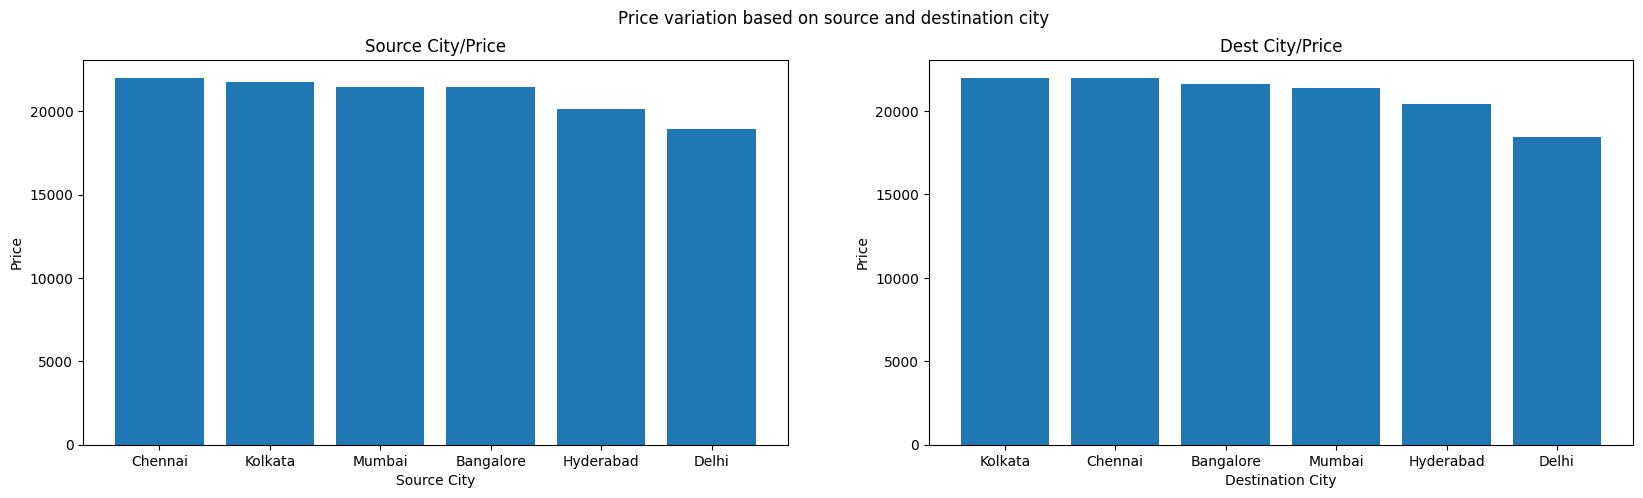

In [39]:
plt.figure(figsize=(20, 5))
plt.suptitle('Price variation based on source and destination city')

plt.subplot(1, 2, 1)
plt.bar(src_prc['source_city'], src_prc['price'])
plt.title('Source City/Price')
plt.xlabel('Source City')
plt.ylabel('Price')

plt.subplot(1, 2, 2)
plt.bar(dest_prc['destination_city'], dest_prc['price'])
plt.title('Dest City/Price')
plt.xlabel('Destination City')
plt.ylabel('Price')

plt.grid(False)
plt.show()


It seems in source city Chennai, Kolkata and Mumbai being expensive city and 
in destination city Kolkata, Chennai and Banglore being expensive city

In [36]:
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
index,,,,,,,,,,,
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


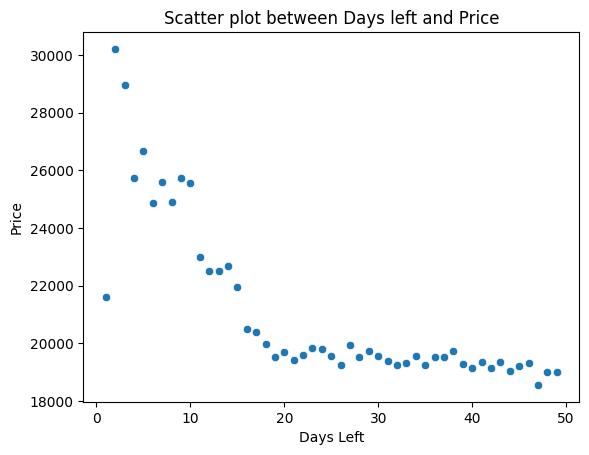

In [42]:
days_lft_price = df.groupby(['days_left'])['price'].mean().reset_index().sort_values('price', ascending=False)

sns.scatterplot(data=days_lft_price, x='days_left', y='price')
plt.title('Scatter plot between Days left and Price')
plt.xlabel('Days Left')
plt.ylabel('Price')

plt.show()

It concludes that the early booking results in lower flight price than booking new flight take off day

What will be the Average Price of Vistara airline for a flight from Delhi to Hyderabad in Business Class ?

In [51]:
# df.loc[(df['airline'] == 'Vistara') & (df['class'] == 'Business')]
vistara_avg_price = df.groupby(['airline', 'class'])['price'].mean().reset_index().round(2)
vistara_avg_price = vistara_avg_price.loc[(vistara_avg_price['airline'] == 'Vistara') & (vistara_avg_price['class'] == 'Business')]
vistara_avg_price

,airline,class,price
6,Vistara,Business,55477.03


The average price for Vistara airline in Business class is $55477.03